# BERT vs GEMMA 4 for Financial News Sentiment Analysis
**Business Problem:** Automating sentiment classification of financial news to support investment decision-making.

**Dataset:** NOSIBLE Financial Sentiment - 100,000 LLM-annotated financial news samples (sampled to 10,000 for training).

**Models:** BERT (fine-tuned) vs Gemma 4 E2B (zero-shot and few-shot prompting)

## Environment Setup & Imports

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import optuna
import time
from collections import Counter
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

#Set seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

#Check device used (to utilize GPU)
device = "cuda" if torch.cuda.is_available() else "CPU"
print(f"Using device: {device}")

Using device: cuda


## Dataset Selection & Preparation
The **NOSIBLE Financial Sentiment** dataset is used, sourced from HuggingFace. This dataset contains 100,000 cleaned, deduplicated, and sentiment-labeled financial news samples from web-scale media surveillance.

Since 100k samples is more than needed for BERT fine-tuning, we take a stratified sample of 10,000 sentences to balance training quality with efficiency.

**Labels:** negative, neutral, positive (string format)

In [2]:
dataset = load_dataset("NOSIBLE/financial-sentiment")
df_full = pd.DataFrame(dataset["train"])
print(f"Dataset: {len(df_full)} samples")
print(df_full["label"].value_counts())

#Sample 10,000 to keep training manageable
SAMPLE_SIZE = 10000
df, _ = train_test_split(df_full, train_size=SAMPLE_SIZE, random_state=SEED, stratify=df_full["label"])
df = df.reset_index(drop=True)

label2id = {"negative": 0, "neutral": 1, "positive": 2}
label_map = {0: "negative", 1: "neutral", 2: "positive"}
df["label_int"] = df["label"].map(label2id)
df["label_name"] = df["label"]
df["sentence"] = df["text"]

print(f"\nSample: {len(df)} sentences")
print(df["label_name"].value_counts())
print(df["label_name"].value_counts(normalize=True).round(3))

Dataset: 100000 samples
label
neutral     39309
positive    36257
negative    24434
Name: count, dtype: int64

Sample: 10000 sentences
label_name
neutral     3931
positive    3626
negative    2443
Name: count, dtype: int64
label_name
neutral     0.393
positive    0.363
negative    0.244
Name: proportion, dtype: float64


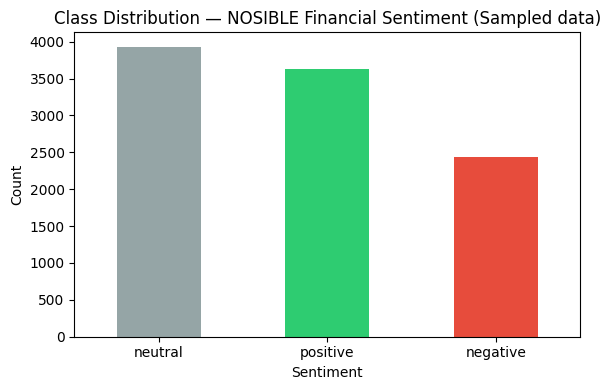

In [3]:
#Visualisation of class distribution
fig, ax = plt.subplots(figsize=(6, 4))
df["label_name"].value_counts().plot(kind="bar", color=["#95a5a6", "#2ecc71", "#e74c3c"], ax=ax)
ax.set_title("Class Distribution — NOSIBLE Financial Sentiment (Sampled data)")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [4]:
#Sample sentences from each class
for label_name in ["positive", "neutral", "negative"]:
    print(f"\n{label_name.upper()}")
    samples = df[df["label_name"] == label_name]["sentence"].sample(3, random_state=SEED)
    for s in samples:
        print(f"  - {s[:150]}")


POSITIVE
  - Plus500 revealed that this performance was achieved due to the company's innovative marketing program that mainly involved partnerships with third par
  - As that slide notes, ConocoPhillips has quality assets as the company possesses a diverse, low-decline asset base that deliver stable cash flow. It ha
  - Moreover, the growing awareness about the benefits of gluten-free diets and the potential harm of gluten for certain individuals is encouraging more c

NEUTRAL
  - Toctino® was developed and successfully brought to market by Basilea. In the U.S., oral alitretinoin is an investigational drug in phase 3 and not yet
  - Kemsley, 44 Misc. 3d 773 (N.Y. Sup. 2014) (chapter 15 recognition was not necessary to enforce, at the request of an individual debtor, a discharge or
  - DALTON, Ga., April 18, 2019 (GLOBE NEWSWIRE) -- You are invited to participate in a conference call with the management of THE DIXIE GROUP, INC (NASDA

NEGATIVE
  - Selling, general and administrative e

## Train/Test Split
A stratified 70/15/15 split. The validation set is used during training to monitor performance per epoch, while the test set is fully held out and only used for final evaluation.

In [5]:
#First split: 70% train, 30% temp
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["sentence"].tolist(),
    df["label_int"].tolist(),
    test_size=0.3,
    random_state=SEED,
    stratify=df["label_int"].tolist(),
)

#Second split: 50/50 on the temp = 15% val, 15% test of original
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels,
)

print(f"Train: {len(train_texts)}")
print(f"Val:   {len(val_texts)}")
print(f"Test:  {len(test_texts)}")
print(f"\nTrain labels: {Counter(train_labels)}")
print(f"Val labels:   {Counter(val_labels)}")
print(f"Test labels:  {Counter(test_labels)}")

Train: 7000
Val:   1500
Test:  1500

Train labels: Counter({1: 2752, 2: 2538, 0: 1710})
Val labels:   Counter({1: 590, 2: 544, 0: 366})
Test labels:  Counter({1: 589, 2: 544, 0: 367})


## BERT Fine-Tuning
### Tokenisation
WordPiece tokenizer from bert-base-uncased with max sequence length of 256 tokens. The token length statistics below show this covers the vast majority of samples.

In [6]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

#Sentence breakdown
sample = "The company reported strong quarterly earnings growth, beating analyst expectations."
print(tokenizer.tokenize(sample))
print(tokenizer.encode(sample))

#Text length check
text_lengths = df["sentence"].apply(lambda x: len(tokenizer.encode(x)))
print(text_lengths.describe())
print(f"% under 256: {(text_lengths <= 256).mean()*100:.1f}%")

['the', 'company', 'reported', 'strong', 'quarterly', 'earnings', 'growth', ',', 'beating', 'analyst', 'expectations', '.']
[101, 1996, 2194, 2988, 2844, 12174, 16565, 3930, 1010, 6012, 12941, 10908, 1012, 102]
count    10000.000000
mean       126.112800
std         56.429975
min         21.000000
25%         77.000000
50%        121.000000
75%        177.000000
max        467.000000
Name: sentence, dtype: float64
% under 256: 99.7%


### Preprocessing & Dataset Creation

In [7]:
from datasets import Dataset

train_dataset = Dataset.from_dict({"text": train_texts, "label": train_labels})
val_dataset = Dataset.from_dict({"text": val_texts, "label": val_labels})
test_dataset = Dataset.from_dict({"text": test_texts, "label": test_labels})

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding=False, max_length=256)

train_dataset = train_dataset.map(tokenize_fn, batched=True)
val_dataset = val_dataset.map(tokenize_fn, batched=True)
test_dataset = test_dataset.map(tokenize_fn, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print(train_dataset[0].keys())

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

dict_keys(['label', 'input_ids', 'attention_mask'])


### Model Initialisation & Hyperparameters
bert-base-uncased is fine-tuned with a 3-class classification head. Baseline hyperparameters before Optuna tuning:

- Learning rate: 2e-5 (standard for BERT fine-tuning)
- Batch size: 32
- Epochs: 3
- Weight decay: 0.01
- Warmup steps: 100

These are then compared against Optuna-optimised hyperparameters

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, local_files_only=True,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./bert_financial_sentiment",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    fp16=True,
    dataloader_num_workers=0,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    seed=SEED,
    report_to="none",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")
    return {"accuracy": accuracy_score(labels, preds), "precision": prec, "recall": rec, "f1_macro": f1}

print(f"Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Params: 109,484,547


### Training

In [9]:
#Initialise Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

#Check GPU is used
print(next(model.parameters()).device)
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Current device: {torch.cuda.current_device()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")
print(f"GPU memory allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

train_result = trainer.train()
print(f"Loss: {train_result.training_loss:.4f}")

trainer.save_model("./bert_baseline_model")

cuda:0
CUDA available: True
Current device: 0
GPU name: NVIDIA GeForce RTX 4080
GPU memory allocated: 0.41 GB
GPU memory reserved: 0.46 GB


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Macro
1,0.597534,0.536582,0.764667,0.768200,0.787869,0.764914
2,0.411047,0.456434,0.811333,0.812944,0.819885,0.814378
3,0.274654,0.476428,0.813333,0.817227,0.812005,0.814301


Loss: 0.5057


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Loss Curves (Baseline)

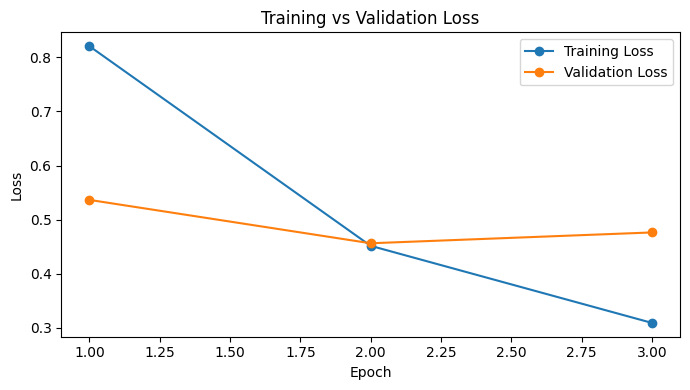

Validation loss decreased — model is still learning


In [10]:
#Plot training vs validation loss per epoch
log_history = trainer.state.log_history

train_loss = [x["loss"] for x in log_history if "loss" in x and "eval_loss" not in x]
eval_entries = [x for x in log_history if "eval_loss" in x]
eval_loss = [x["eval_loss"] for x in eval_entries]
eval_epochs = [x["epoch"] for x in eval_entries]

#Average training loss per epoch
steps_per_epoch = len(train_loss) // len(eval_loss) if eval_loss else 1
train_loss_per_epoch = [
    np.mean(train_loss[i * steps_per_epoch:(i + 1) * steps_per_epoch])
    for i in range(len(eval_loss))
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eval_epochs, train_loss_per_epoch, "o-", label="Training Loss")
ax.plot(eval_epochs, eval_loss, "o-", label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()

if eval_loss[-1] > eval_loss[0]:
    print("Validation loss increased — possible overfitting")
elif eval_loss[-1] < eval_loss[0]:
    print("Validation loss decreased — model is still learning")

In [11]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

baseline_preds_output = trainer.predict(test_dataset)
baseline_preds = np.argmax(baseline_preds_output.predictions, axis=-1)

print("Baseline results:")
print(classification_report(test_labels, baseline_preds, target_names=["negative", "neutral", "positive"]))

Baseline results:
              precision    recall  f1-score   support

    negative       0.82      0.89      0.85       367
     neutral       0.80      0.77      0.79       589
    positive       0.83      0.82      0.82       544

    accuracy                           0.82      1500
   macro avg       0.82      0.83      0.82      1500
weighted avg       0.82      0.82      0.82      1500



### Hyperparameter Optimisation with Optuna
Rather than manually selecting hyperparameters, Optuna was used to search the hyperparameter space.

Search space:
- Learning rate: 1e-5 to 5e-5 (log scale)
- Batch size: 8, 16
- Epochs: 2-4
- Weight decay: 0.0-0.1
- Warmup steps: 0-200

15 trials were run, optimising for macro F1 score.

In [12]:
import optuna

def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3, id2label=label_map, label2id={v: k for k, v in label_map.items()},
    )

torch.cuda.empty_cache()

def hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16]),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 4),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1),
        "warmup_steps": trial.suggest_int("warmup_steps", 0, 200),
    }

optuna_trainer = Trainer(
    model_init=model_init,
    args=TrainingArguments(
        output_dir="./bert_optuna_search",
        eval_strategy="epoch",
        save_strategy="no",
        per_device_eval_batch_size=64,
        logging_steps=50,
        seed=SEED,
        report_to="none",
        fp16=True,
        dataloader_num_workers=0,
    ),
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

N_TRIALS = 15
best_trial = optuna_trainer.hyperparameter_search(
    direction="maximize", hp_space=hp_space, n_trials=N_TRIALS, backend="optuna",
)

print(f"Best F1: {best_trial.objective:.4f}")
print(best_trial.hyperparameters)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[I 2026-04-14 10:39:15,355] A new stu

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Macro
1,0.527539,0.478132,0.808000,0.807463,0.817581,0.810227
2,0.341752,0.457276,0.821333,0.825648,0.820311,0.822651


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Macro
1,0.548541,0.483800,0.798000,0.804782,0.802321,0.801252


[I 2026-04-14 10:58:06,577] Trial 14 pruned. 


Best F1: 3.3112
{'learning_rate': 4.8049461092359234e-05, 'per_device_train_batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.05119549283100081, 'warmup_steps': 40}


### Retrain with Optimised Hyperparameters

In [13]:
best_hp = best_trial.hyperparameters

torch.cuda.empty_cache()

optimised_args = TrainingArguments(
    output_dir="./bert_optimised",
    num_train_epochs=best_hp["num_train_epochs"],
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=best_hp["learning_rate"],
    weight_decay=best_hp["weight_decay"],
    warmup_steps=best_hp["warmup_steps"],
    eval_strategy="epoch",
    save_strategy="no",
    fp16=True,
    dataloader_num_workers=0,
    seed=SEED,
    report_to="none",
)

optimised_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=label_map, label2id={v: k for k, v in label_map.items()},
).to("cuda")

trainer = Trainer(
    model=optimised_model,
    args=optimised_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print(f"Loss: {train_result.training_loss:.4f}")
trainer.save_model("./bert_optimised_model")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Macro
1,No log,0.514470,0.788000,0.797249,0.797886,0.790632
2,0.610961,0.477608,0.815333,0.817760,0.816585,0.817162


Loss: 0.4798


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Loss Curves (Optimised)

C:\Users\wooho\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\wooho\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


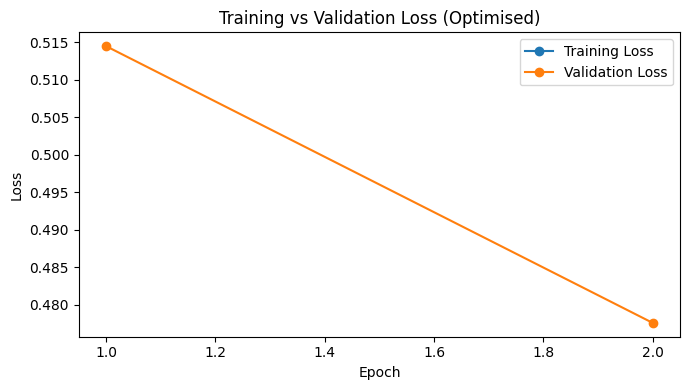

In [14]:
log_history = trainer.state.log_history

train_loss = [x["loss"] for x in log_history if "loss" in x and "eval_loss" not in x]
eval_entries = [x for x in log_history if "eval_loss" in x]
eval_loss = [x["eval_loss"] for x in eval_entries]
eval_epochs = [x["epoch"] for x in eval_entries]

steps_per_epoch = len(train_loss) // len(eval_loss) if eval_loss else 1
train_loss_per_epoch = [
    np.mean(train_loss[i * steps_per_epoch:(i + 1) * steps_per_epoch])
    for i in range(len(eval_loss))
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eval_epochs, train_loss_per_epoch, "o-", label="Training Loss")
ax.plot(eval_epochs, eval_loss, "o-", label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss (Optimised)")
ax.legend()
plt.tight_layout()
plt.show()

### Best F1 and Hyperparameters
Which hyperparameters had the most impact

In [15]:
print(f"Best F1: {best_trial.objective:.4f}")
print(f"Best hyperparameters: {best_trial.hyperparameters}")

Best F1: 3.3112
Best hyperparameters: {'learning_rate': 4.8049461092359234e-05, 'per_device_train_batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.05119549283100081, 'warmup_steps': 40}


### BERT Evaluation (Optimised Model)

In [16]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

bert_results = trainer.evaluate()
print(bert_results)

{'eval_loss': 0.4776075482368469, 'eval_accuracy': 0.8153333333333334, 'eval_precision': 0.8177603634360823, 'eval_recall': 0.8165845246591736, 'eval_f1_macro': 0.8171621825467978, 'eval_runtime': 1.3475, 'eval_samples_per_second': 1113.185, 'eval_steps_per_second': 34.88, 'epoch': 2.0}


In [17]:
bert_preds_output = trainer.predict(test_dataset)
bert_preds = np.argmax(bert_preds_output.predictions, axis=-1)

print(classification_report(test_labels, bert_preds, target_names=["negative", "neutral", "positive"]))

              precision    recall  f1-score   support

    negative       0.82      0.89      0.85       367
     neutral       0.81      0.79      0.80       589
    positive       0.84      0.81      0.82       544

    accuracy                           0.82      1500
   macro avg       0.82      0.83      0.82      1500
weighted avg       0.82      0.82      0.82      1500



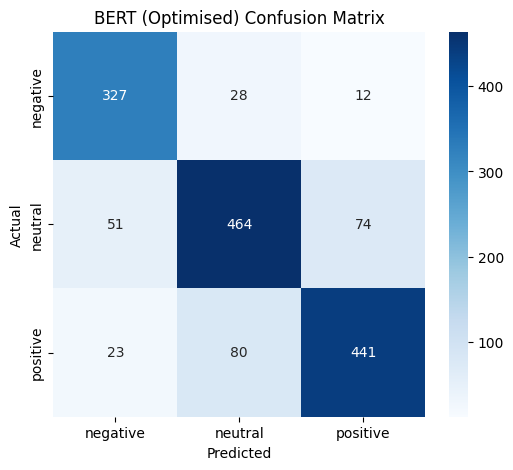

In [18]:
cm = confusion_matrix(test_labels, bert_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"], ax=ax)
ax.set_title("BERT (Optimised) Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.show()

In [19]:
from sklearn.metrics import f1_score

baseline_metrics = {
    "Accuracy": accuracy_score(test_labels, baseline_preds),
    "F1 (Macro)": f1_score(test_labels, baseline_preds, average="macro"),
}
optimised_metrics = {
    "Accuracy": accuracy_score(test_labels, bert_preds),
    "F1 (Macro)": f1_score(test_labels, bert_preds, average="macro"),
}

comparison = pd.DataFrame({"Baseline": baseline_metrics, "Optimised": optimised_metrics})
comparison["Improvement"] = comparison["Optimised"] - comparison["Baseline"]
print(comparison.round(4))

            Baseline  Optimised  Improvement
Accuracy      0.8167     0.8213       0.0047
F1 (Macro)    0.8209     0.8248       0.0039


## Load Gemma 4

In [20]:
from huggingface_hub import login
login()

In [21]:
torch.cuda.empty_cache()

from transformers import AutoTokenizer, AutoModelForCausalLM

GEMMA_MODEL = "google/gemma-4-e2b-it"

gemma_tokenizer = AutoTokenizer.from_pretrained(GEMMA_MODEL)
gemma_model = AutoModelForCausalLM.from_pretrained(
    GEMMA_MODEL, dtype=torch.float16, device_map="auto",
)

print(f"Memory: {torch.cuda.memory_allocated(0)/1024**3:.1f} GB")

config.json: 0.00B [00:00, ?B/s]

C:\Users\wooho\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\wooho\.cache\huggingface\hub\models--google--gemma-4-e2b-it. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

Memory: 12.5 GB


### Prompt Design

In [22]:
for label in ["positive", "negative", "neutral"]:
    sample = df[df["label"] == label]["text"].sample(1, random_state=42).values[0]
    print(f"\n{label}")
    print(sample)


positive
Plus500 revealed that this performance was achieved due to the company's innovative marketing program that mainly involved partnerships with third party marketers and affiliates. This way, most of the actual marketing activity was conducted by third party collaborators, allowing the company to focus on the betterment of its actual services.

negative
Selling, general and administrative expenses increased by 6.6% to $667.8 million, and increased 10 basis points to 29.0% of net sales. The slight increase in SG&A as a percentage of net sales was driven primarily by increases in other store costs and other corporate-related expenses to support the continued growth of the business and additional personnel costs from the Company-operated stores acquired in the United Grocery Outlet transaction in April of last year, partially offset by a decrease from elective commission support we provided to operators in the prior year related to the systems conversion, lower incentive compensati

In [23]:
def build_zero_shot(sentence):
    return f"""Classify this financial news sentence as exactly one of: positive, negative, or neutral.
Respond with ONLY the label. No explanation.

Sentence: "{sentence}"
Label:"""

FEW_SHOT_EXAMPLES = """Sentence: "Plus500 revealed that this performance was achieved due to the company's innovative marketing program that mainly involved partnerships with third party marketers and affiliates."
Label: positive

Sentence: "Selling, general and administrative expenses increased by 6.6% to $667.8 million. Operating loss during the first half was $9.7 million, which included $45.0 million in charges related to the Restructuring Plan."
Label: negative

Sentence: "Toctino was developed and successfully brought to market by Basilea. In the U.S., oral alitretinoin is an investigational drug in phase 3 and not yet approved by the FDA."
Label: neutral"""

def build_few_shot(sentence):
    return f"""Classify financial news sentences as positive, negative, or neutral.

{FEW_SHOT_EXAMPLES}

Sentence: "{sentence}"
Label:"""

def classify_gemma(prompt):
    messages = [{"role": "user", "content": prompt}]
    inputs = gemma_tokenizer.apply_chat_template(messages, return_tensors="pt", return_dict=True, add_generation_prompt=True).to("cuda")
    
    with torch.no_grad():
        outputs = gemma_model.generate(**inputs, max_new_tokens=10, do_sample=False)
    
    response = gemma_tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip().lower()
    
    for label in ["positive", "negative", "neutral"]:
        if label in response:
            return label
    return "unknown"

test_sentence = "Net profit dropped to EUR 3.1 million from EUR 8.3 million."
print(f"Test: {classify_gemma(build_zero_shot(test_sentence))}")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Test: negative


### Sample and Evaluation

In [24]:
GENAI_SAMPLE_SIZE = 500
test_df = pd.DataFrame({"sentence": test_texts, "label": test_labels})
genai_sample, _ = train_test_split(test_df, train_size=GENAI_SAMPLE_SIZE, random_state=SEED, stratify=test_df["label"])
genai_sample = genai_sample.reset_index(drop=True)
print(f"Sample: {len(genai_sample)} sentences")
print(f"Columns: {genai_sample.columns.tolist()}")

print("Zero-shot")
zero_shot_preds = []
for i, row in genai_sample.iterrows():
    pred = classify_gemma(build_zero_shot(row["sentence"]))
    zero_shot_preds.append(pred)
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{len(genai_sample)}")
print(f"Unknown: {zero_shot_preds.count('unknown')}")

print("Few-shot")
few_shot_preds = []
for i, row in genai_sample.iterrows():
    pred = classify_gemma(build_few_shot(row["sentence"]))
    few_shot_preds.append(pred)
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{len(genai_sample)}")
print(f"Unknown: {few_shot_preds.count('unknown')}")

Sample: 500 sentences
Columns: ['sentence', 'label']
Zero-shot
  50/500
  100/500
  150/500
  200/500
  250/500
  300/500
  350/500
  400/500
  450/500
  500/500
Unknown: 0
Few-shot
  50/500
  100/500
  150/500
  200/500
  250/500
  300/500
  350/500
  400/500
  450/500
  500/500
Unknown: 1


### Results

In [25]:
label2id = {"negative": 0, "neutral": 1, "positive": 2}
true_labels_sample = genai_sample["label"].tolist()

zs_numeric = [label2id.get(p, -1) for p in zero_shot_preds]
fs_numeric = [label2id.get(p, -1) for p in few_shot_preds]

# filter unknowns
zs_clean = [(p, t) for p, t in zip(zs_numeric, true_labels_sample) if p != -1]
fs_clean = [(p, t) for p, t in zip(fs_numeric, true_labels_sample) if p != -1]
zs_preds, zs_true = zip(*zs_clean) if zs_clean else ([], [])
fs_preds, fs_true = zip(*fs_clean) if fs_clean else ([], [])

print(f"Valid zero-shot: {len(zs_preds)}/{len(genai_sample)}")
print(f"Valid few-shot: {len(fs_preds)}/{len(genai_sample)}")

print("\n=== Zero-Shot ===")
print(classification_report(list(zs_true), list(zs_preds), target_names=["negative", "neutral", "positive"]))

print("=== Few-Shot ===")
print(classification_report(list(fs_true), list(fs_preds), target_names=["negative", "neutral", "positive"]))

Valid zero-shot: 500/500
Valid few-shot: 499/500

=== Zero-Shot ===
              precision    recall  f1-score   support

    negative       0.88      0.86      0.87       122
     neutral       0.72      0.59      0.65       196
    positive       0.69      0.85      0.76       182

    accuracy                           0.75       500
   macro avg       0.77      0.76      0.76       500
weighted avg       0.75      0.75      0.74       500

=== Few-Shot ===
              precision    recall  f1-score   support

    negative       0.73      0.87      0.79       122
     neutral       0.88      0.34      0.49       195
    positive       0.61      0.92      0.73       182

    accuracy                           0.68       499
   macro avg       0.74      0.71      0.67       499
weighted avg       0.74      0.68      0.65       499



### Confusion Matrix

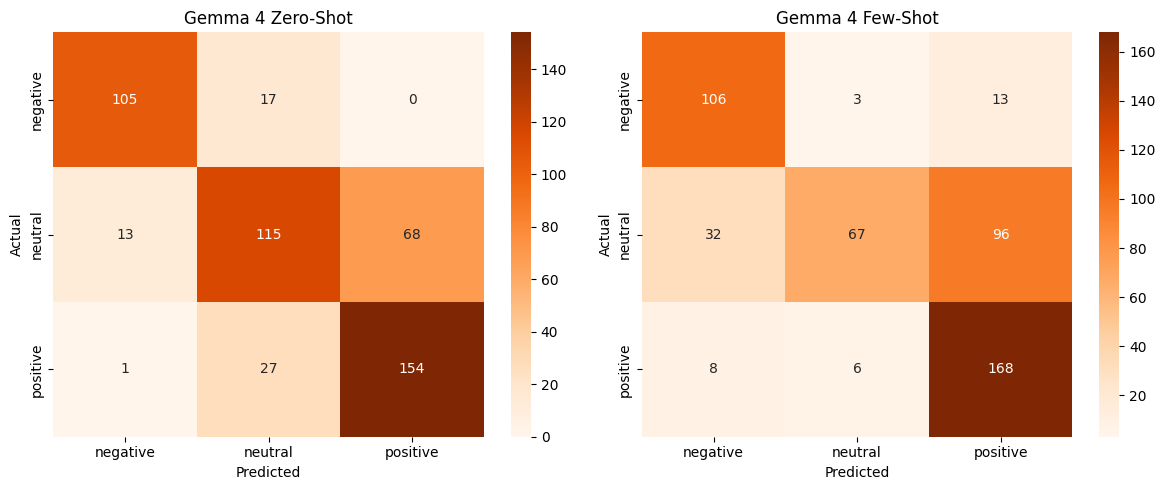

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, true, title in [
    (axes[0], list(zs_preds), list(zs_true), "Gemma 4 Zero-Shot"),
    (axes[1], list(fs_preds), list(fs_true), "Gemma 4 Few-Shot"),
]:
    cm = confusion_matrix(true, preds, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                xticklabels=["negative", "neutral", "positive"],
                yticklabels=["negative", "neutral", "positive"], ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## Model Comparison

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

                     Accuracy  Precision  Recall  F1 (Macro)
Model                                                       
BERT (Optimised)       0.8000     0.8001  0.8100      0.8040
Gemma 4 (Zero-Shot)    0.7480     0.7664  0.7645      0.7605
Gemma 4 (Few-Shot)     0.6834     0.7380  0.7118      0.6725


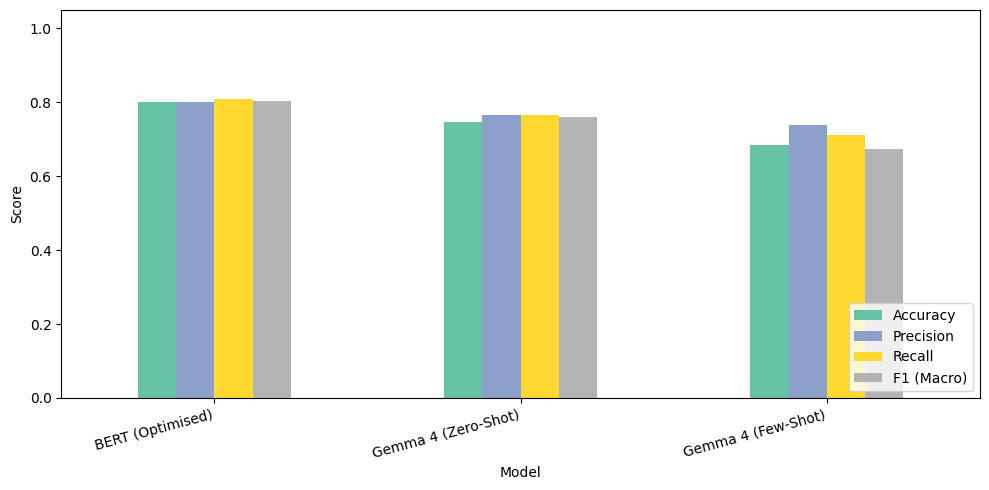

In [27]:
def get_metrics(true, preds, name):
    acc = accuracy_score(true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(true, preds, average="macro")
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1 (Macro)": f1}

# reload BERT predictions for comparison
bert_model = AutoModelForSequenceClassification.from_pretrained("./bert_optimised_model").to("cuda")
bert_trainer = Trainer(model=bert_model, processing_class=tokenizer, data_collator=data_collator)

# get BERT preds on same sample
bert_sample_preds = []
for _, row in genai_sample.iterrows():
    inputs = tokenizer(row["sentence"], truncation=True, max_length=256, return_tensors="pt").to("cuda")
    with torch.no_grad():
        logits = bert_model(**inputs).logits
    bert_sample_preds.append(logits.argmax(-1).item())

comparison = pd.DataFrame([
    get_metrics(true_labels_sample, bert_sample_preds, "BERT (Optimised)"),
    get_metrics(list(zs_true), list(zs_preds), "Gemma 4 (Zero-Shot)"),
    get_metrics(list(fs_true), list(fs_preds), "Gemma 4 (Few-Shot)"),
]).set_index("Model")
print(comparison.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
comparison.plot(kind="bar", ax=ax, colormap="Set2")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Error Analysis

In [28]:
genai_sample_with_preds = genai_sample.copy()
genai_sample_with_preds["true_label"] = genai_sample["label"].map(label_map)
genai_sample_with_preds["zs_pred"] = zero_shot_preds
genai_sample_with_preds["fs_pred"] = few_shot_preds

# get BERT predictions on same samples
bert_preds_sample = []
for _, row in genai_sample.iterrows():
    inputs = tokenizer(row["sentence"], truncation=True, max_length=256, return_tensors="pt").to("cuda")
    with torch.no_grad():
        logits = bert_model(**inputs).logits
    bert_preds_sample.append(label_map[logits.argmax(-1).item()])
genai_sample_with_preds["bert_pred"] = bert_preds_sample

# where BERT was right but Gemma (zero-shot) was wrong
bert_right = genai_sample_with_preds[
    (genai_sample_with_preds["bert_pred"] == genai_sample_with_preds["true_label"]) &
    (genai_sample_with_preds["zs_pred"] != genai_sample_with_preds["true_label"])
]

# where Gemma was right but BERT was wrong
gemma_right = genai_sample_with_preds[
    (genai_sample_with_preds["zs_pred"] == genai_sample_with_preds["true_label"]) &
    (genai_sample_with_preds["bert_pred"] != genai_sample_with_preds["true_label"])
]

print(f"BERT correct, Gemma wrong: {len(bert_right)}")
print(f"Gemma correct, BERT wrong: {len(gemma_right)}")

print("\nBERT correct, Gemma wrong")
for _, row in bert_right.head(3).iterrows():
    print(f"  {row['sentence'][:120]}...")
    print(f"  True: {row['true_label']} | BERT: {row['bert_pred']} | Gemma: {row['zs_pred']}\n")

print("Gemma correct, BERT wrong")
for _, row in gemma_right.head(3).iterrows():
    print(f"  {row['sentence'][:120]}...")
    print(f"  True: {row['true_label']} | BERT: {row['bert_pred']} | Gemma: {row['zs_pred']}\n")

BERT correct, Gemma wrong: 84
Gemma correct, BERT wrong: 58

BERT correct, Gemma wrong
  There's no telling if Starboard will prevail in a looming proxy fight with Yahoo. But the hedge fund has achieved a fear...
  True: neutral | BERT: neutral | Gemma: negative

  Although a 2017 remediation plan compensated for this issue, plaintiffs in the Wells Fargo auto loan class action argued...
  True: negative | BERT: negative | Gemma: neutral

  If the transaction materializes, it will allow the companies to cut costs, share infrastructure and pool capital. Poor f...
  True: negative | BERT: negative | Gemma: neutral

Gemma correct, BERT wrong
  Portillo's ( PTLO 3.24% ) is a high-growth restaurant chain with a growth strategy that looks a lot like some successful...
  True: positive | BERT: neutral | Gemma: positive

  Ideal for a variety of skidding applications, the new grapple increases productivity in thinning or heavy load applicati...
  True: positive | BERT: neutral | Gemma: positive

## Inference Time Comparison
Deployment cost and scalability

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT: 5.53s for 500 samples (11.1ms per sample)
Gemma 4: 5.05s for 50 samples (101.0ms per sample)
Gemma 4 (extrapolated to 500): 50.5s

BERT is ~9x faster than Gemma 4 for classification


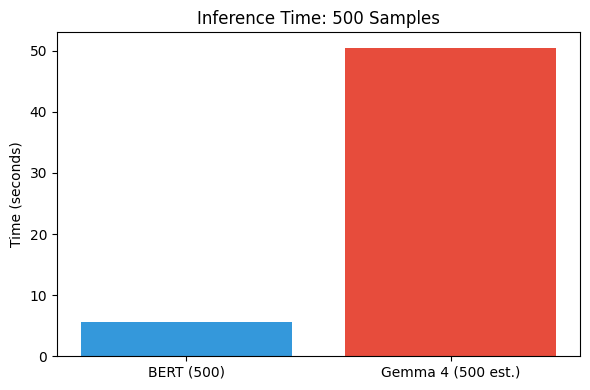

In [29]:
timing_sample = test_texts[:500]

#BERT inference timing
bert_model_timing = AutoModelForSequenceClassification.from_pretrained("./bert_optimised_model").to("cuda")
bert_model_timing.eval()

torch.cuda.synchronize()
start = time.time()
for sentence in timing_sample:
    inputs = tokenizer(sentence, truncation=True, max_length=256, return_tensors="pt").to("cuda")
    with torch.no_grad():
        _ = bert_model_timing(**inputs).logits
torch.cuda.synchronize()
bert_time = time.time() - start

print(f"BERT: {bert_time:.2f}s for 500 samples ({bert_time/500*1000:.1f}ms per sample)")

#Gemma inference timing
torch.cuda.synchronize()
start = time.time()
for sentence in timing_sample[:50]:
    prompt = build_zero_shot(sentence)
    messages = [{"role": "user", "content": prompt}]
    inputs = gemma_tokenizer.apply_chat_template(messages, return_tensors="pt", return_dict=True, add_generation_prompt=True).to("cuda")
    with torch.no_grad():
        _ = gemma_model.generate(**inputs, max_new_tokens=10, do_sample=False)
torch.cuda.synchronize()
gemma_time = time.time() - start
gemma_time_500 = gemma_time / 50 * 500

print(f"Gemma 4: {gemma_time:.2f}s for 50 samples ({gemma_time/50*1000:.1f}ms per sample)")
print(f"Gemma 4 (extrapolated to 500): {gemma_time_500:.1f}s")
print(f"\nBERT is ~{gemma_time_500/bert_time:.0f}x faster than Gemma 4 for classification")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["BERT (500)", "Gemma 4 (500 est.)"], [bert_time, gemma_time_500], color=["#3498db", "#e74c3c"])
ax.set_ylabel("Time (seconds)")
ax.set_title("Inference Time: 500 Samples")
plt.tight_layout()
plt.show()